## Statsforecast for GPU Utilization

### Without exogeneous variables

In [50]:
from statsforecast import StatsForecast

In [51]:
import pandas as pd

In [52]:
Y_df = pd.read_csv('gpu_slurm_metrics_10s_cleaned.csv') # load the data
Y_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259185 entries, 0 to 1259184
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   timestamp               1259185 non-null  object 
 1   gpu_index               1259185 non-null  int64  
 2   utilization_gpu_pct     1259185 non-null  float64
 3   utilization_memory_pct  1259185 non-null  float64
 4   temperature_gpu         1259185 non-null  float64
 5   temperature_memory      1259185 non-null  float64
 6   power_draw_W            1259185 non-null  float64
 7   id_job                  1259185 non-null  int64  
 8   time_start              1259185 non-null  float64
 9   time_end                1259185 non-null  float64
dtypes: float64(7), int64(2), object(1)
memory usage: 96.1+ MB


In [53]:
Y_df['unique_id'] = Y_df['id_job'].astype(str) + '_gpu' + Y_df['gpu_index'].astype(str)

In [54]:
Y_df['timestamp'] = pd.to_datetime(Y_df['timestamp'])
Y_df = Y_df.sort_values(by=['unique_id', 'timestamp'])

In [55]:
# Create a numerical index 'ds' that starts from 0 for each series.
# This is crucial for Nixtla models and handles variable start times and durations.
Y_df['ds'] = Y_df.groupby('unique_id').cumcount()

In [56]:
Y_df['y'] = Y_df['utilization_gpu_pct']

In [57]:
Y_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1259185 entries, 264388 to 463474
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   timestamp               1259185 non-null  datetime64[ns]
 1   gpu_index               1259185 non-null  int64         
 2   utilization_gpu_pct     1259185 non-null  float64       
 3   utilization_memory_pct  1259185 non-null  float64       
 4   temperature_gpu         1259185 non-null  float64       
 5   temperature_memory      1259185 non-null  float64       
 6   power_draw_W            1259185 non-null  float64       
 7   id_job                  1259185 non-null  int64         
 8   time_start              1259185 non-null  float64       
 9   time_end                1259185 non-null  float64       
 10  unique_id               1259185 non-null  object        
 11  ds                      1259185 non-null  int64         
 12  y              

In [58]:
# This is the standard format for Nixtla.
prepared_df = Y_df[['unique_id', 'ds', 'y']]

print("Data prepared successfully. Head of the DataFrame:")
print(prepared_df.head())
print(f"\nNumber of unique time series (job-gpu combinations): {prepared_df['unique_id'].nunique()}")

Data prepared successfully. Head of the DataFrame:
                  unique_id  ds         y
264388  10217518336509_gpu0   0  6.360656
471025  10217518336509_gpu0   1  0.435484
264389  10217518336509_gpu0   2  0.031915
471026  10217518336509_gpu0   3  0.063830
264390  10217518336509_gpu0   4  1.150538

Number of unique time series (job-gpu combinations): 414


In [16]:
Y_df.head()

,timestamp,gpu_index,utilization_gpu_pct,utilization_memory_pct,temperature_gpu,temperature_memory,power_draw_W,id_job,time_start,time_end,unique_id,ds,y
264388,2021-06-07 20:24:30,0,6.360656,0.360656,65.180328,66.393443,54.939016,10217518336509,1.623112e+09,1.623137e+09,10217518336509_gpu0,0,6.360656
471025,2021-06-07 20:24:30,0,0.435484,0.000000,40.000000,38.080645,46.433710,10217518336509,1.623112e+09,1.623137e+09,10217518336509_gpu0,1,0.435484
264389,2021-06-07 20:24:40,0,0.031915,0.010638,63.638298,64.861702,53.556915,10217518336509,1.623112e+09,1.623137e+09,10217518336509_gpu0,2,0.031915
471026,2021-06-07 20:24:40,0,0.063830,0.021277,40.000000,38.042553,46.569681,10217518336509,1.623112e+09,1.623137e+09,10217518336509_gpu0,3,0.063830
264390,2021-06-07 20:24:50,0,1.150538,0.032258,62.311828,63.387097,52.611935,10217518336509,1.623112e+09,1.623137e+09,10217518336509_gpu0,4,1.150538


In [15]:
# h = (5 minutes * 60 seconds/minute) / 10 seconds/sample = 30 steps
h = 30

# Split data into training and testing sets
# The test set is the last 'h' steps of EACH time series.
train_df = prepared_df.groupby('unique_id').head(-h)
test_df = prepared_df.groupby('unique_id').tail(h)

print(f"Training set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")

Training set size: 1246765
Test set size: 12420


In [10]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, Naive

# seasonal_length=6 for 1 minute
sf_models = [
    AutoARIMA(season_length=6),
]

sf = StatsForecast(
    models=sf_models,
    freq=1, # Since we created an integer 'ds' index
    n_jobs=-1 # Use all available cores
)

# 3. Get predictions
# The forecast method takes the training data and predicts 'h' steps for each series.
# Note: StatsForecast is smart and uses the last available data from train_df to forecast.
forecast_sf_df = sf.forecast(df=train_df, h=h)

# Merge with true values for evaluation
forecast_sf_df = forecast_sf_df.merge(test_df, on=['unique_id', 'ds'], how='left')

print("StatsForecast predictions:")
print(forecast_sf_df.head())

StatsForecast predictions:
             unique_id    ds  AutoARIMA          y
0  10217518336509_gpu0  5048  93.664716  94.655914
1  10217518336509_gpu0  5049  93.660859  94.978723
2  10217518336509_gpu0  5050  93.661097  94.935484
3  10217518336509_gpu0  5051  93.661082  94.914894
4  10217518336509_gpu0  5052  93.661083  94.279570


In [30]:
forecast_sf_df

,Unnamed: 0,unique_id,ds,AutoARIMA,y
0,0,10217518336509_gpu0,5048,93.664716,94.655914
1,1,10217518336509_gpu0,5049,93.660859,94.978723
2,2,10217518336509_gpu0,5050,93.661097,94.935484
3,3,10217518336509_gpu0,5051,93.661082,94.914894
4,4,10217518336509_gpu0,5052,93.661083,94.279570
...,...,...,...,...,...
12415,12415,9976590120891_gpu1,14525,96.922748,96.072289
12416,12416,9976590120891_gpu1,14526,96.074509,97.168675
12417,12417,9976590120891_gpu1,14527,96.135934,96.626506
12418,12418,9976590120891_gpu1,14528,96.955086,98.867470


In [36]:
fcst_no_e = forecast_sf_df[["unique_id", "ds", "AutoARIMA"]]

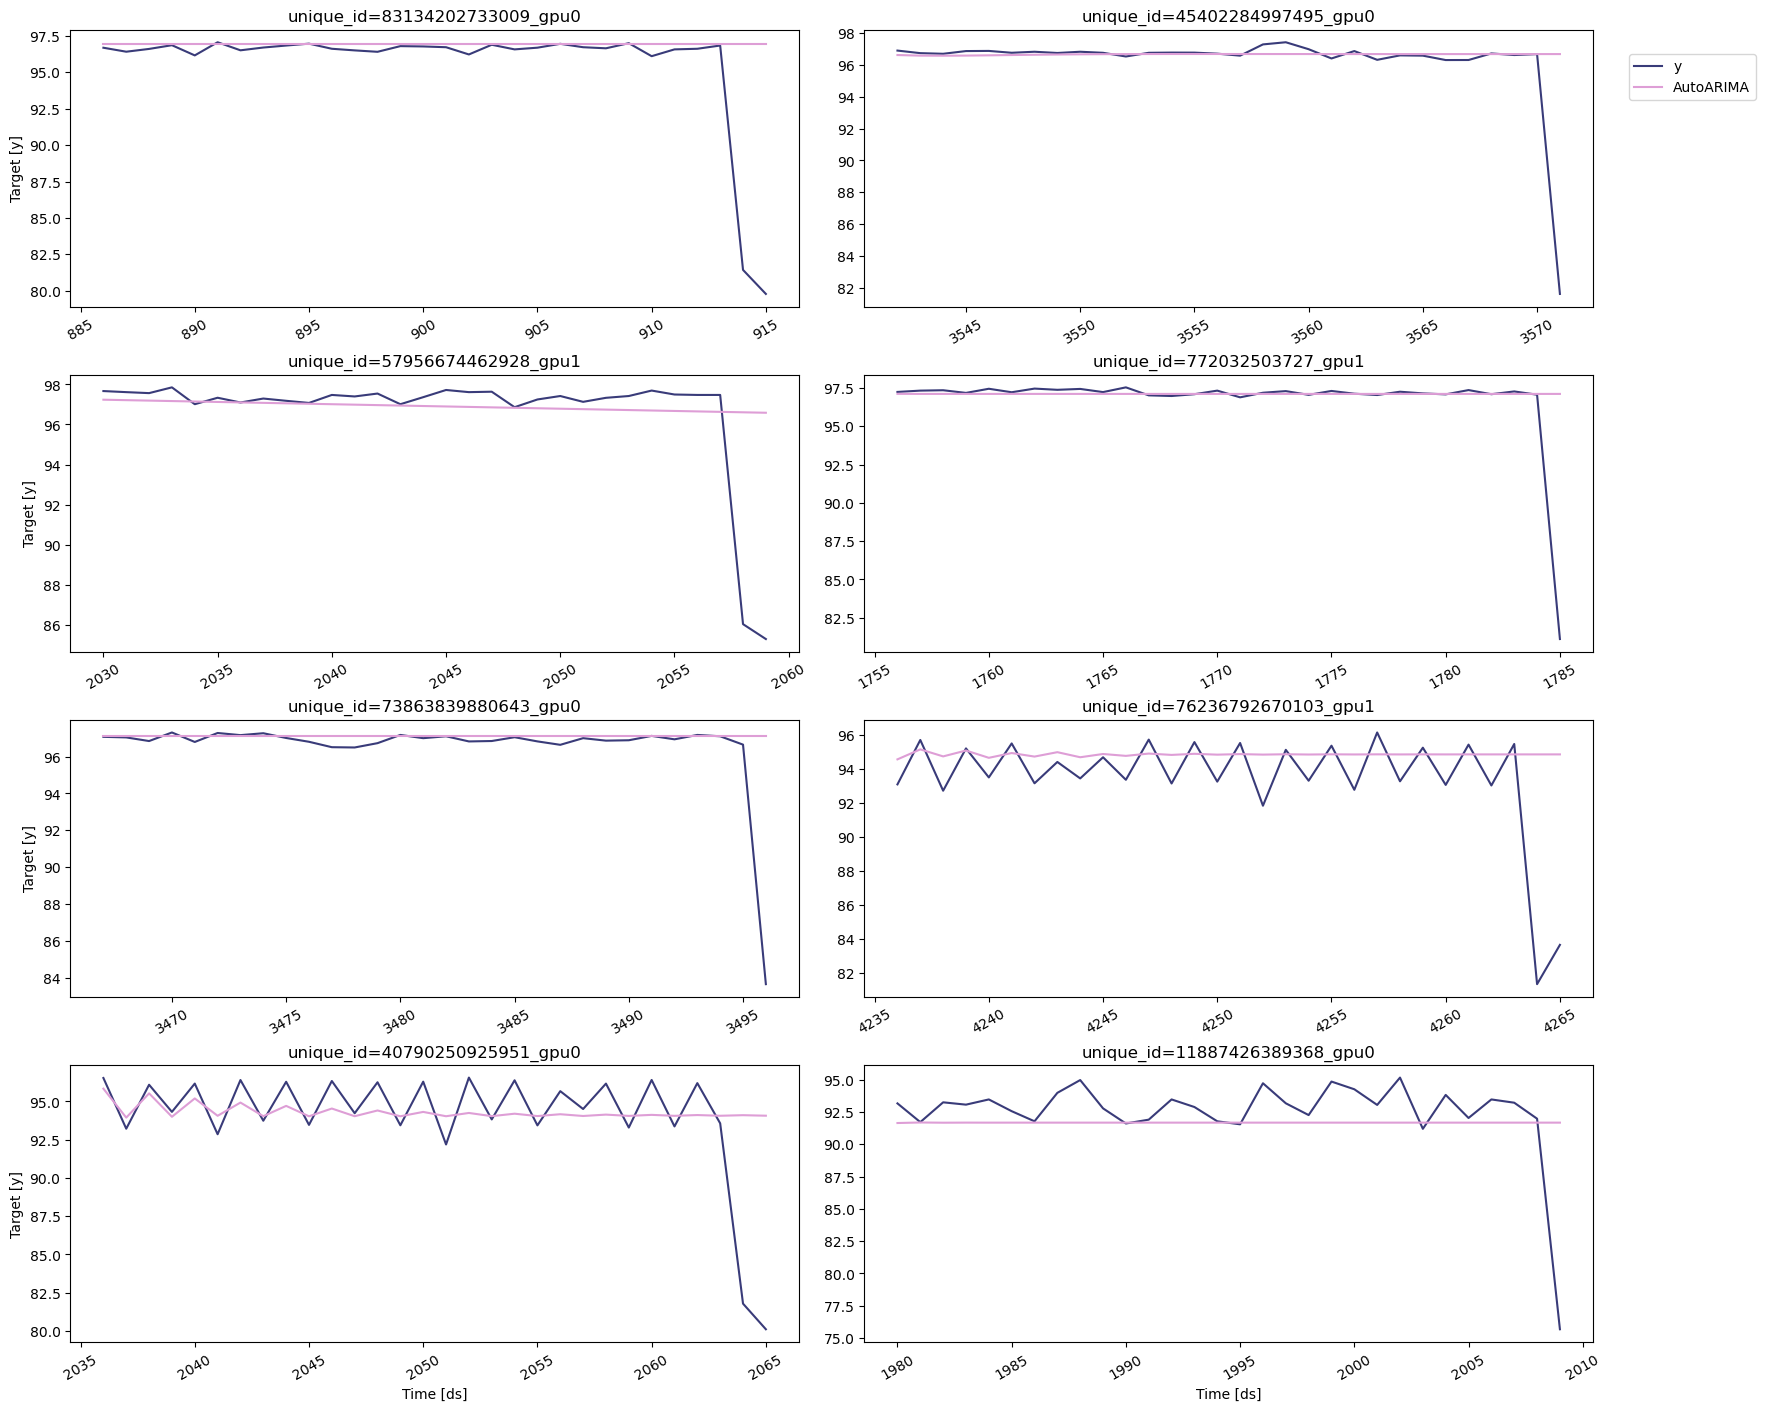

In [37]:
StatsForecast.plot(test_df, fcst_no_e, max_insample_length=30*2)

In [15]:
forecast_sf_df.to_csv("auto-arima-results.csv")

In [3]:
forecast_sf_df = pd.read_csv("auto-arima-results.csv")

In [4]:
import polars as pl
from utilsforecast.losses import mae, rmse, mse, mape, smape

def evaluate_forecast(df, forecast_col="AutoARIMA", y_col="y", id_col="unique_id"):
    # Convert pandas → polars
    pl_df = pl.from_pandas(df[[id_col, forecast_col, y_col]])
    
    results = {
        "MAE": mae(pl_df, models=[forecast_col], id_col=id_col, target_col=y_col),
        "RMSE": rmse(pl_df, models=[forecast_col], id_col=id_col, target_col=y_col),
        "MSE": mse(pl_df, models=[forecast_col], id_col=id_col, target_col=y_col),
        "MAPE": mape(pl_df, models=[forecast_col], id_col=id_col, target_col=y_col),
        "sMAPE": smape(pl_df, models=[forecast_col], id_col=id_col, target_col=y_col),
    }
    
    # Each metric returns a polars DataFrame → convert & merge
    metrics_df = results["MAE"]
    for k, v in results.items():
        metrics_df = metrics_df.join(v, on=id_col, how="inner", suffix=f"_{k}")
    
    return metrics_df.to_pandas()

# Example usage
per_series_metrics = evaluate_forecast(forecast_sf_df)
print(per_series_metrics.head())


             unique_id  AutoARIMA  AutoARIMA_MAE  AutoARIMA_RMSE  \
0  10217518336509_gpu0   2.451605       2.451605        5.500946   
1  10217518336509_gpu1   1.878616       1.878616        6.040135   
2  10297115157410_gpu1   0.825499       0.825499        3.534229   
3  10612452483078_gpu0   1.174242       1.174242        4.980247   
4  10612452483078_gpu1   1.130905       1.130905        5.313863   

   AutoARIMA_MSE  AutoARIMA_MAPE  AutoARIMA_sMAPE  
0      30.260404        0.030289         0.013982  
1      36.483236        0.025437         0.011157  
2      12.490773        0.010208         0.004642  
3      24.802858        0.015784         0.006828  
4      28.237142        0.015940         0.006712  


In [5]:
import polars as pl
import pandas as pd
from utilsforecast.losses import mae, rmse, mse, mape, smape

def evaluate_forecast(df, forecast_col="AutoARIMA", y_col="y", id_col="unique_id"):
    # Convert pandas → polars
    pl_df = pl.from_pandas(df[[id_col, forecast_col, y_col]])

    # --- Per-series metrics ---
    metrics = {
        "MAE": mae(pl_df, models=[forecast_col], id_col=id_col, target_col=y_col),
        "RMSE": rmse(pl_df, models=[forecast_col], id_col=id_col, target_col=y_col),
        "MSE": mse(pl_df, models=[forecast_col], id_col=id_col, target_col=y_col),
        "MAPE": mape(pl_df, models=[forecast_col], id_col=id_col, target_col=y_col),
        "sMAPE": smape(pl_df, models=[forecast_col], id_col=id_col, target_col=y_col),
    }

    # Merge all metrics into one polars df
    per_series = metrics["MAE"]
    for k, v in metrics.items():
        per_series = per_series.join(v, on=id_col, how="inner", suffix=f"_{k}")

    per_series = per_series.rename({forecast_col: "MAE", f"{forecast_col}_RMSE": "RMSE",
                                    f"{forecast_col}_MSE": "MSE", f"{forecast_col}_MAPE": "MAPE",
                                    f"{forecast_col}_sMAPE": "sMAPE"}).to_pandas()

    # --- Weighted MAPE per series ---
    df["_abs_err"] = (df[y_col] - df[forecast_col]).abs()
    df["_abs_y"] = df[y_col].abs()
    wmape_series = df.groupby(id_col).apply(lambda x: x["_abs_err"].sum() / x["_abs_y"].sum()).reset_index()
    wmape_series.columns = [id_col, "wMAPE"]
    per_series = per_series.merge(wmape_series, on=id_col)

    # --- Global metrics ---
    y_true = df[y_col].values
    y_pred = df[forecast_col].values
    global_metrics = {
        "MAE": (abs(y_true - y_pred)).mean(),
        "RMSE": ((y_true - y_pred)**2).mean()**0.5,
        "MSE": ((y_true - y_pred)**2).mean(),
        "MAPE": (abs((y_true - y_pred) / y_true)).mean() * 100,
        "sMAPE": (200 * abs(y_true - y_pred) / (abs(y_true) + abs(y_pred))).mean(),
        "wMAPE": (abs(y_true - y_pred).sum() / abs(y_true).sum()) * 100
    }
    global_metrics = pd.DataFrame([global_metrics])

    return per_series, global_metrics


In [6]:
per_series_metrics, global_metrics = evaluate_forecast(forecast_sf_df)

print("Per-series metrics:")
print(per_series_metrics.head())

print("\nGlobal metrics:")
print(global_metrics)


Per-series metrics:
             unique_id       MAE  AutoARIMA_MAE      RMSE        MSE  \
0  10217518336509_gpu0  2.451605       2.451605  5.500946  30.260404   
1  10217518336509_gpu1  1.878616       1.878616  6.040135  36.483236   
2  10297115157410_gpu1  0.825499       0.825499  3.534229  12.490773   
3  10612452483078_gpu0  1.174242       1.174242  4.980247  24.802858   
4  10612452483078_gpu1  1.130905       1.130905  5.313863  28.237142   

       MAPE     sMAPE     wMAPE  
0  0.030289  0.013982  0.026268  
1  0.025437  0.011157  0.020254  
2  0.010208  0.004642  0.008593  
3  0.015784  0.006828  0.012206  
4  0.015940  0.006712  0.011761  

Global metrics:
        MAE      RMSE        MSE  MAPE     sMAPE     wMAPE
0  2.353625  8.086333  65.388776   inf  2.997481  2.517407


/tmp/ipykernel_2338/2376992982.py:41: RuntimeWarning: divide by zero encountered in divide
  "MAPE": (abs((y_true - y_pred) / y_true)).mean() * 100,


### With exogeneous regressors

In [17]:
Y_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1259185 entries, 264388 to 463474
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   timestamp               1259185 non-null  datetime64[ns]
 1   gpu_index               1259185 non-null  int64         
 2   utilization_gpu_pct     1259185 non-null  float64       
 3   utilization_memory_pct  1259185 non-null  float64       
 4   temperature_gpu         1259185 non-null  float64       
 5   temperature_memory      1259185 non-null  float64       
 6   power_draw_W            1259185 non-null  float64       
 7   id_job                  1259185 non-null  int64         
 8   time_start              1259185 non-null  float64       
 9   time_end                1259185 non-null  float64       
 10  unique_id               1259185 non-null  object        
 11  ds                      1259185 non-null  int64         
 12  y              

In [19]:
Y_ts = Y_df[['unique_id', 'ds', 'y']]

In [20]:
exog_vars = ['utilization_memory_pct', 'temperature_gpu', 'temperature_memory', 'power_draw_W']
X_ts = Y_df[['unique_id', 'ds'] + exog_vars]

In [22]:
X_ts['unique_id'] = X_ts.unique_id.astype(str)
X_ts.info()

/tmp/ipykernel_2338/1014213204.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_ts['unique_id'] = X_ts.unique_id.astype(str)


<class 'pandas.core.frame.DataFrame'>
Index: 1259185 entries, 264388 to 463474
Data columns (total 6 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   unique_id               1259185 non-null  object 
 1   ds                      1259185 non-null  int64  
 2   utilization_memory_pct  1259185 non-null  float64
 3   temperature_gpu         1259185 non-null  float64
 4   temperature_memory      1259185 non-null  float64
 5   power_draw_W            1259185 non-null  float64
dtypes: float64(4), int64(1), object(1)
memory usage: 67.2+ MB


In [23]:
# h = (5 minutes * 60 seconds/minute) / 10 seconds/sample = 30 steps
h = 30

# Split data into training and testing sets
# The test set is the last 'h' steps of EACH time series.
Y_train = Y_ts.groupby('unique_id').head(-h)
Y_test = Y_ts.groupby('unique_id').tail(h)

X_train = X_ts.groupby('unique_id').head(-h)
X_test = X_ts.groupby('unique_id').tail(h)

print(f"Training set size: {len(Y_train)}")
print(f"Test set size: {len(Y_test)}")

Training set size: 1246765
Test set size: 12420


In [24]:
train = Y_train.merge(X_ts, how = 'left', on = ['unique_id', 'ds']) 
train.head()

,unique_id,ds,y,utilization_memory_pct,temperature_gpu,temperature_memory,power_draw_W
0,10217518336509_gpu0,0,6.360656,0.360656,65.180328,66.393443,54.939016
1,10217518336509_gpu0,1,0.435484,0.000000,40.000000,38.080645,46.433710
2,10217518336509_gpu0,2,0.031915,0.010638,63.638298,64.861702,53.556915
3,10217518336509_gpu0,3,0.063830,0.021277,40.000000,38.042553,46.569681
4,10217518336509_gpu0,4,1.150538,0.032258,62.311828,63.387097,52.611935


In [25]:
X_test.head()

,unique_id,ds,utilization_memory_pct,temperature_gpu,temperature_memory,power_draw_W
266912,10217518336509_gpu0,5048,32.516129,67.956989,70.602151,167.222043
473549,10217518336509_gpu0,5049,32.851064,68.159574,68.489362,182.227021
266913,10217518336509_gpu0,5050,32.602151,67.784946,70.408602,170.289140
473550,10217518336509_gpu0,5051,33.329787,68.297872,68.776596,183.194681
266914,10217518336509_gpu0,5052,32.526882,68.010753,70.827957,171.555484


In [26]:
from statsforecast.models import AutoARIMA

In [27]:
models = [AutoARIMA(season_length=6)]

In [30]:
sf = StatsForecast(
    models=models, 
    freq=1, 
    n_jobs=-1,
)

In [31]:
horizon = 30

fcst = sf.forecast(df=train, h=horizon, X_df=X_test)
fcst.head()

,unique_id,ds,AutoARIMA
0,10217518336509_gpu0,5048,93.850326
1,10217518336509_gpu0,5049,94.329221
2,10217518336509_gpu0,5050,94.395725
3,10217518336509_gpu0,5051,95.249313
4,10217518336509_gpu0,5052,94.662197


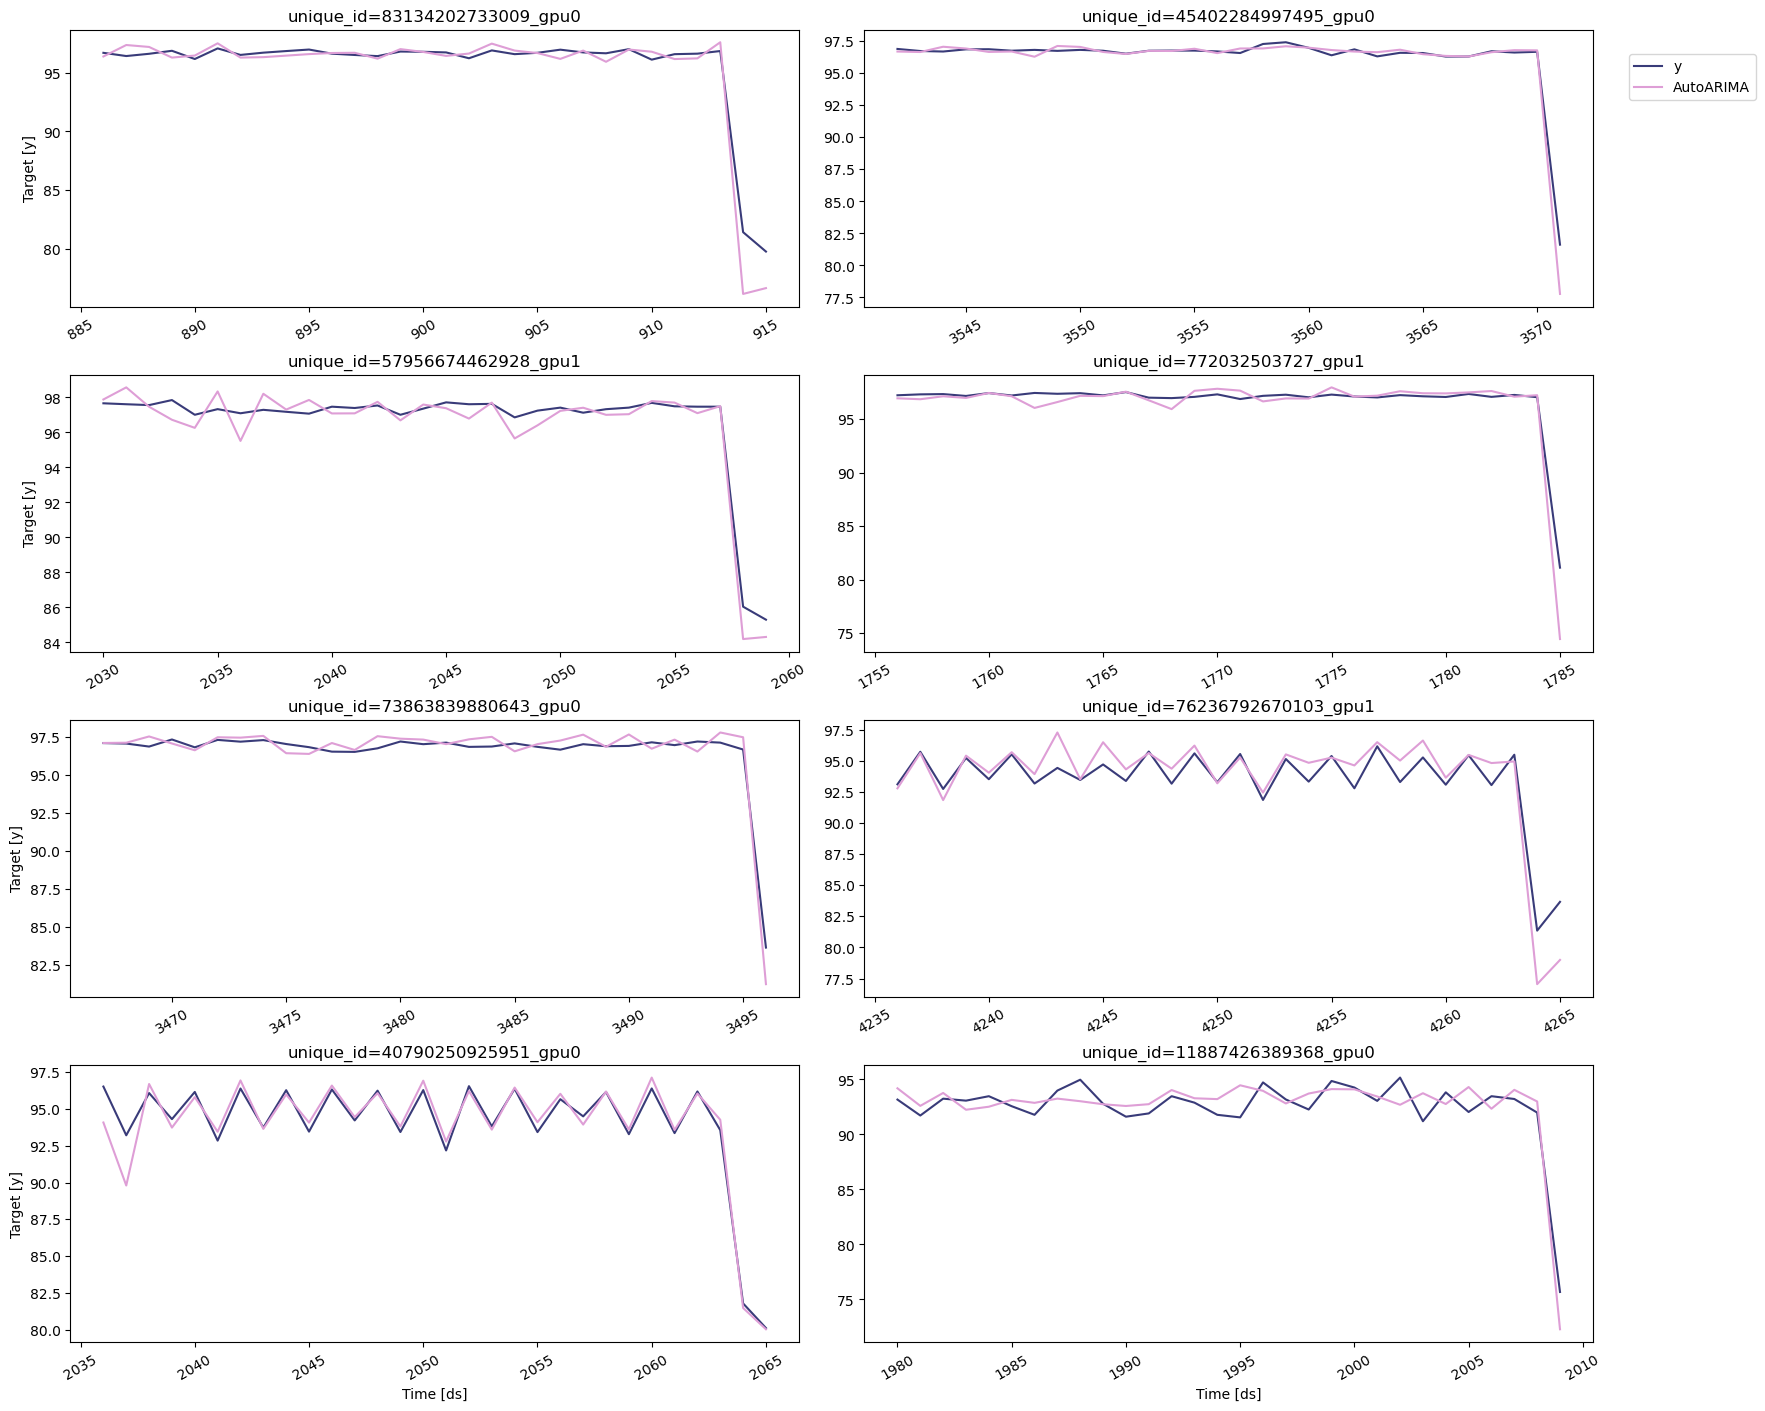

In [41]:
StatsForecast.plot(Y_ts, fcst, max_insample_length=15*2)

In [33]:
res = Y_test.merge(fcst, how='left', on=['unique_id', 'ds'])
res.head()

,unique_id,ds,y,AutoARIMA
0,10217518336509_gpu0,5048,94.655914,93.850326
1,10217518336509_gpu0,5049,94.978723,94.329221
2,10217518336509_gpu0,5050,94.935484,94.395725
3,10217518336509_gpu0,5051,94.914894,95.249313
4,10217518336509_gpu0,5052,94.279570,94.662197


In [34]:
per_series_metrics, global_metrics = evaluate_forecast(res)

print("Per-series metrics:")
print(per_series_metrics.head())

print("\nGlobal metrics:")
print(global_metrics)

Per-series metrics:
             unique_id       MAE  AutoARIMA_MAE      RMSE       MSE      MAPE  \
0  10217518336509_gpu0  0.567910       0.567910  0.639121  0.408476  0.006228   
1  10217518336509_gpu1  0.634697       0.634697  1.133957  1.285857  0.007653   
2  10297115157410_gpu1  0.598825       0.598825  1.541035  2.374787  0.006893   
3  10612452483078_gpu0  0.410832       0.410832  0.621301  0.386014  0.004565   
4  10612452483078_gpu1  0.306080       0.306080  0.507798  0.257859  0.003474   

      sMAPE     wMAPE  
0  0.003114  0.006085  
1  0.003879  0.006843  
2  0.003543  0.006234  
3  0.002296  0.004271  
4  0.001745  0.003183  

Global metrics:
        MAE      RMSE        MSE  MAPE     sMAPE     wMAPE
0  1.194345  5.273579  27.810637   inf  2.348611  1.277456


/tmp/ipykernel_2338/2376992982.py:41: RuntimeWarning: divide by zero encountered in divide
  "MAPE": (abs((y_true - y_pred) / y_true)).mean() * 100,
